In [1]:
import tensorflow as tf
import numpy as np
import keras
from keras import Input,Model
from keras.layers import Dense,Dropout,GlobalAveragePooling2D
from keras.losses import CategoricalCrossentropy
from keras.metrics import AUC
import matplotlib.pyplot as plt
import os
import glob
import torch
from torchvision.transforms import v2
from torchvision.datasets import DatasetFolder
from torch.utils.data import DataLoader
import math
from datetime import datetime
import random
from kaggle_secrets import UserSecretsClient

try:
    import wandb
except:
    !pip install wandb
    import wandb
from wandb.integration.keras import WandbMetricsLogger

os.environ["KERAS_BACKEND"] = "tensorflow"
now = datetime.now()
date = now.strftime("%Y %m %d")

In [2]:
K = tf.keras.backend

In [3]:
# set seed for reproducibility
keras.utils.set_random_seed(42)
random.seed(42)
np.random.seed(42)

In [4]:
data_format = "channels_last"
keras.config.set_image_data_format(data_format)
print(f"Data channel format: {keras.config.image_data_format()}")

Data channel format: channels_last


In [5]:
# strategy = tf.distribute.MirroredStrategy()
# print(f"Number of GPUs: {strategy.num_replicas_in_sync}")

In [6]:
class C:
    raw_path = "/kaggle/input/gsoc-2024"
    train_data = os.path.join(raw_path,"dataset/train")
    val_data = os.path.join(raw_path,"dataset/val")
    weights = f"weights_{date}.weights.h5"
    num_classes = 3
    epochs = 50
    batch_size = 128
    height = 150
    shape = [height,height]
    base_lr = 1e-4
    # autotune = tf.data.experimental.AUTOTUNE
    # buffer = 1024
    

In [7]:
# wandb setup
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("my_dash")
!wandb login $secret_value_0

wandb.init(
    project="GSOC25_DeepLense_Test",
    config={
        "learning_rate": C.base_lr,
        "batch_size": C.batch_size,
        "augmentation scheme": "center_crop, affine transformation and perspective transformation",
        "model": "Resnet50"
    },
    group = "Test 1",
    job_type = "supervised"
)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: atiaisaac007. Use `wandb login --relogin` to force relogin
wandb: Tracking run with wandb version 0.19.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20250305_111707-7x475ub4
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run peach-energy-6
wandb: ⭐️ View project at https://wandb.ai/atiaisaac007/GSOC25_DeepLense_Test
wandb: 🚀 View run at https://wandb.ai/atiaisaac007/GSOC25_DeepLense_Test/runs/7x475ub4


In [8]:
def npy_loader(path):
    sample = np.load(path)
    tensor = torch.from_numpy(sample).float()
    return tensor

def target_transform(label):
    return torch.eye(3)[label]

In [9]:
print("number of images in train 'no': {}".format(len(glob.glob(os.path.join(C.train_data,"no/*")))))
print("number of images in train 'sphere': {}".format(len(glob.glob(os.path.join(C.train_data,"sphere/*")))))
print("number of images in train 'vort': {}".format(len(glob.glob(os.path.join(C.train_data,"vort/*")))))

number of images in train 'no': 10000
number of images in train 'sphere': 10000
number of images in train 'vort': 10000


In [10]:
print("number of images in validation 'no': {}".format(len(glob.glob(os.path.join(C.val_data,"no/*")))))
print("number of images in validation 'sphere': {}".format(len(glob.glob(os.path.join(C.val_data,"sphere/*")))))
print("number of images in validation 'vort': {}".format(len(glob.glob(os.path.join(C.val_data,"vort/*")))))

number of images in validation 'no': 2500
number of images in validation 'sphere': 2500
number of images in validation 'vort': 2500


In [11]:
class RepeatChannels(object):
    def __init__(self, num_channels=3):
        self.num_channels = num_channels
        
    def __call__(self, x):
        # If x is a tensor with shape [H, W] or [1, H, W]
        if len(x.shape) == 2:  # [H, W]
            x = x.unsqueeze(0)  # Add channel dimension -> [1, H, W]
        
        if x.shape[0] == 1:  # If single channel [1, H, W]
            x = x.repeat(self.num_channels, 1, 1)  # Repeat to [3, H, W]
            x = x.permute(1, 2, 0)
        
        return x

In [12]:
train_dataset = DatasetFolder(
    root=C.train_data,
    loader=npy_loader,
    extensions=('.npy',),
    transform=v2.Compose([
        v2.ToImage(),
        v2.RandomApply(
            transforms = [
                v2.RandomAffine(
            degrees=(0,90),
            translate=(0.1,0.3),
            # scale=(0.3, 0.5),
        )
            ],
            p = 0.3
        ),
        # v2.RandomPerspective(
        #     distortion_scale=0.3,
        #     p=0.3
        # ),
        RepeatChannels(3)
    ]),
    target_transform=target_transform
)

val_dataset = DatasetFolder(
    root=C.val_data,
    loader=npy_loader,
    extensions=('.npy',),
    transform=v2.Compose([
        v2.ToImage(),
        RepeatChannels(3),
    ]),
    target_transform=target_transform
)

In [13]:
train_loader = DataLoader(train_dataset, batch_size=C.batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=C.batch_size, shuffle=True, num_workers=0)

In [14]:
def visualize_batch(dataloader, num_batches=1, class_names=None):
    if class_names is None:
        class_names = list(dataloader.dataset.class_to_idx.keys())
    
    # Get a batch of images
    for batch_idx, (images, labels) in enumerate(dataloader):
        if batch_idx >= num_batches:
            break
            
        # Convert tensors to numpy for plotting
        images = images.numpy()
        
        # Create a grid of subplots
        fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(12, 12))
        axes = axes.flatten()
        
        # Plot each image in the batch
        for i in range(min(16, len(images))):
            img = images[i]
            label = torch.argmax(labels[i], axis=0).item()
            
            # Determine how to display the image based on its shape
            if len(img.shape) == 3:  # Color image (C, H, W)
                if img.shape[2] == 1:  # Single channel
                    axes[i].imshow(img[0], cmap='gray')
                else:  # Multiple channels (e.g., RGB)
                    # Move channels to the end for matplotlib (H, W, C)
                    # img_display = np.transpose(img, (1, 2, 0))
                    img_display = img
                    # If more than 3 channels, just use first 3
                    if img_display.shape[2] > 3:
                        img_display = img_display[:, :, :3]
                    axes[i].imshow(img_display)
            elif len(img.shape) == 2:  # Grayscale image (H, W)
                axes[i].imshow(img, cmap='gray')
            else:  # Handle other shapes appropriately
                axes[i].text(0.5, 0.5, f"Shape: {img.shape}", 
                             ha='center', va='center', transform=axes[i].transAxes)
            
            # Add class label
            axes[i].set_title(f"Class: {class_names[label]}")
            axes[i].axis('off')
            
        plt.tight_layout()
        plt.suptitle(f"Batch {batch_idx+1}")
        plt.show()

In [15]:
dummy_dataset = DatasetFolder(
    root=C.train_data,
    loader=npy_loader,
    extensions=('.npy',),
    transform=v2.Compose([
        v2.ToImage(),
        v2.RandomApply(
            transforms = [
                v2.RandomAffine(
            degrees=(0,90),
            translate=(0.1,0.3),
            # scale=(0.3, 0.5),
        )
            ],
            p = 0.3
        ),
        # v2.RandomPerspective(
        #     distortion_scale=0.3,
        #     p=0.3
        # ),
        RepeatChannels(3)
    ]),
    target_transform=target_transform
)
dummy_loader = DataLoader(dummy_dataset, batch_size=16, shuffle=True, num_workers=4)

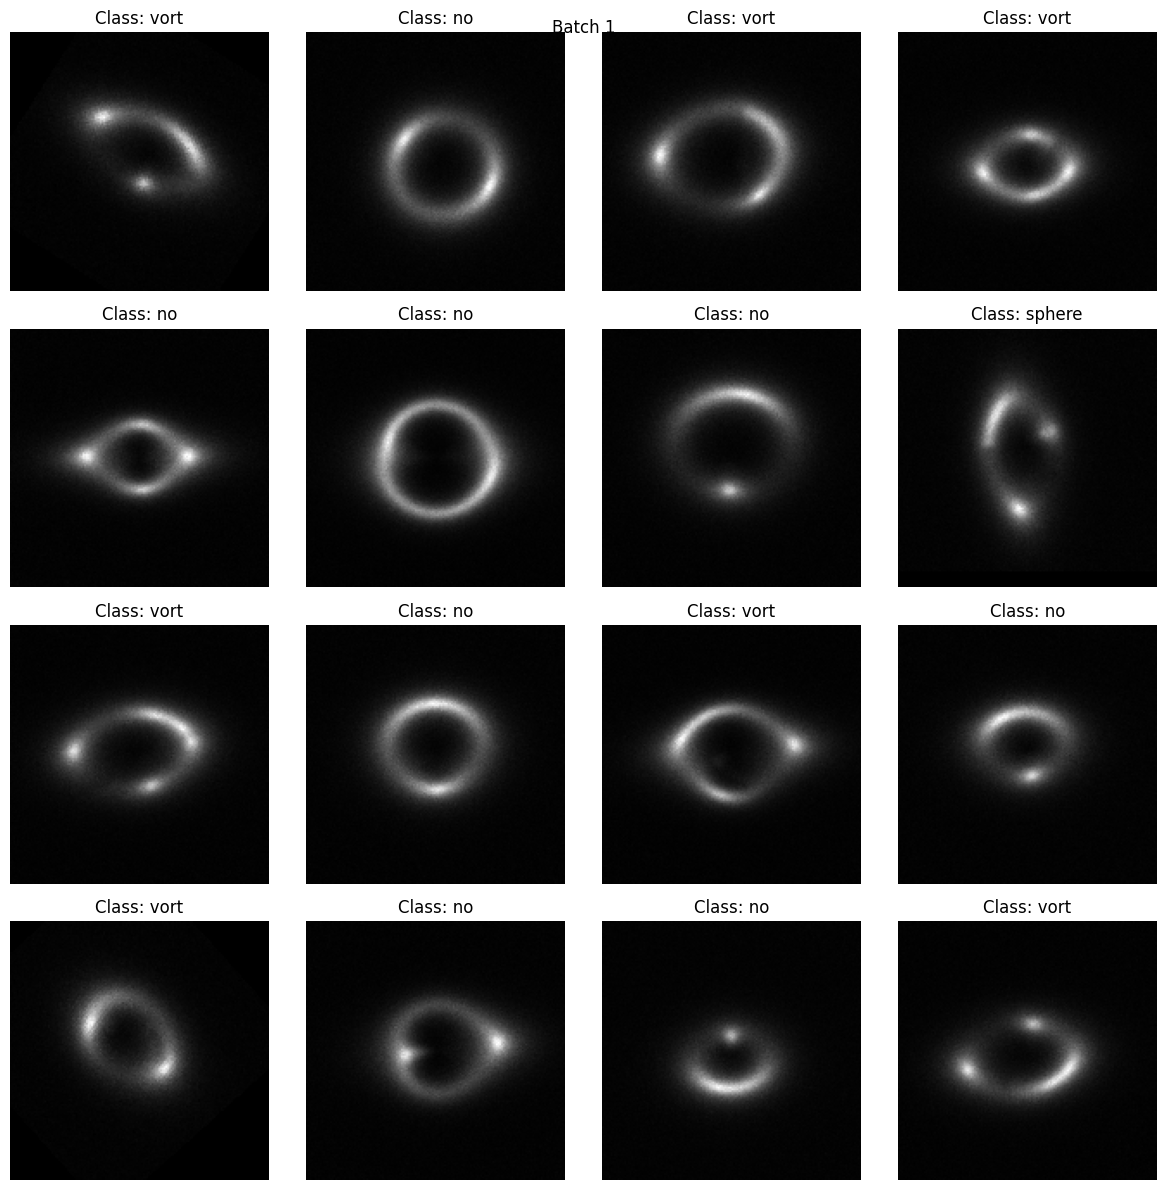

In [16]:
visualize_batch(dummy_loader, num_batches=1, class_names=['no', 'sphere', 'vort'])

In [17]:
# steps_per_epoch = int(np.ceil(30000 / C.batch_size))
# validation_steps = int(np.ceil(7500 / C.batch_size))

In [18]:
def get_model():
  inp = Input(shape=[*C.shape, 3])
  base = keras.applications.resnet50.ResNet50(
      weights = "imagenet",
      include_top = False,
      input_shape = [*C.shape, 3],
  )
  base.trainable = True
  x = keras.applications.resnet.preprocess_input(inp)
  x = base(x,training=True)
  x = GlobalAveragePooling2D()(x)
  out = Dense(C.num_classes,activation="softmax")(x)
  model = Model(inputs=inp,outputs=out)
  model.compile(
      loss = CategoricalCrossentropy,
      optimizer = keras.optimizers.Adam(
          learning_rate = C.base_lr,
#           weight_decay = C.decay
      ),
      metrics = [AUC(name="auc")],
  )
  return model

In [19]:
# with strategy.scope():
deeplense_model = get_model()
deeplense_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 150, 150, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ get_item (GetItem)        │ (None, 150, 150)       │              0 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ get_item_1 (GetItem)      │ (None, 150, 150)       │              0 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ get_item_2 (GetItem)      │ (None, 150, 150)       │              0 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stack (Stack)             │ (None, 150, 150, 3)    │              0 │ get_item[0][0],        │
│                           │                        │                │ get_item_1[0][0],      │
│                           │                        │                │ get_item_2[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add (Add)                 │ (None, 150, 150, 3)    │              0 │ stack[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ resnet50 (Functional)     │ (None, 5, 5, 2048)     │     23,587,712 │ add[0][0]              │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling2d  │ (None, 2048)           │              0 │ resnet50[0][0]         │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 3)              │          6,147 │ global_average_poolin… │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 23,593,859 (90.00 MB)

 Trainable params: 23,540,739 (89.80 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [20]:
class LRScheduler(keras.callbacks.Callback):
    def __init__(self, factor, patience, verbose):
        super().__init__()
        self.factor = factor
        self.patience = patience
        # self.min_lr = min_lr
        self.verbose = verbose
        self.wait = 0
        self.best_loss = float('inf')

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        val_loss = logs.get("val_loss")

        if val_loss is None:
            return  # Skip if val_loss is not available

        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.wait = 0  # Reset patience counter
        else:
            self.wait += 1  # Increment patience counter

            if self.wait >= self.patience:
                current_lr = float(K.get_value(self.model.optimizer.learning_rate))
                new_lr = current_lr * self.factor
                self.model.optimizer.learning_rate.assign(new_lr)

                if self.verbose:
                    print(f"\nEpoch {epoch+1}: Reducing learning rate to {new_lr}")


                self.wait = 0  # Reset patience counter


In [21]:
lr_scheduler = LRScheduler(factor = 0.1, patience = 3, verbose = True)
deeplense_model.fit(
    train_loader,
    # steps_per_epoch = steps_per_epoch,
    validation_data = val_loader,
    # validation_steps = validation_steps, 
    epochs = C.epochs,
    callbacks = [lr_scheduler, WandbMetricsLogger()],
)

# wandb.finish()

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 481s 2s/step - auc: 0.5066 - loss: 1.1544 - val_auc: 0.5002 - val_loss: 1.2678
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 83s 352ms/step - auc: 0.5026 - loss: 1.1250 - val_auc: 0.4987 - val_loss: 1.1044
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 84s 358ms/step - auc: 0.5093 - loss: 1.1151 - val_auc: 0.5028 - val_loss: 1.1036
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 84s 355ms/step - auc: 0.5034 - loss: 1.1133 - val_auc: 0.5057 - val_loss: 1.1221
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 85s 362ms/step - auc: 0.5088 - loss: 1.1115 - val_auc: 0.5009 - val_loss: 1.1180
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 84s 354ms/step - auc: 0.5159 - loss: 1.1048 - val_auc: 0.5023 - val_loss: 1.0987
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 83s 353ms/step - auc: 0.5206 - loss: 1.1104 - val_auc: 0.5000 - val_loss: 17.6570
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 84s 355ms/step - auc: 0.6997 - loss: 0.9678 - val_auc: 0.4976 - val_loss: 4.7031
Epoch 9/50
235/235 ━━━━━━━━━━━━━━

In [22]:
deeplense_model.evaluate(val_loader)

59/59 ━━━━━━━━━━━━━━━━━━━━ 13s 227ms/step - auc: 0.9748 - loss: 0.3270


[0.33366116881370544, 0.9737057089805603]

In [23]:
# deeplense_model.save_weights(os.path.join(wandb.run.dir,C.weights))

In [24]:
deeplense_model.save_weights(C.weights)